In [1]:
!git clone https://github.com/UCT-Advanced-Image-Analysis/semester-project-2026.git

Cloning into 'semester-project-2026'...
remote: Enumerating objects: 564, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 564 (delta 99), reused 40 (delta 40), pack-reused 445 (from 1)
Receiving objects: 100% (564/564), 11.65 MiB | 20.40 MiB/s, done.
Resolving deltas: 100% (225/225), done.


In [2]:
# The only extra install you might need
!pip install pingouin -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.0 MB/s eta 0:00:00


In [3]:


import pandas as pd
import pingouin as pg
from sklearn.metrics import cohen_kappa_score

In [4]:
import glob
import os

search_path = '/content/semester-project-2026/images'
pattern = os.path.join(search_path, '**', 'student_*.csv')

found_files = glob.glob(pattern, recursive=True)

if found_files:
    print("Found 'student_*.csv' files:")
    for file_path in found_files:
        print(file_path)
else:
    print("No 'student_*.csv' files found in the specified path.")

Found 'student_*.csv' files:
/content/semester-project-2026/images/student_09/student_09_counts.csv
/content/semester-project-2026/images/student_03/student_03_counts.csv
/content/semester-project-2026/images/student_06/student_06_counts.csv
/content/semester-project-2026/images/student_02/student_02_counts.csv
/content/semester-project-2026/images/student_08/student_08_counts.csv
/content/semester-project-2026/images/student_05/student_05_counts.csv
/content/semester-project-2026/images/student_07/student_07_counts.csv


Load CSV

In [5]:
import pandas as pd
import re
import os

data = []
for file_path in found_files:
    filename = os.path.basename(file_path)
    match = re.search(r'student_(\d+)_counts\.csv', filename)
    if match:
        student_number = match.group(1)
        data.append({'student_number': student_number, 'path': file_path})

student_df = pd.DataFrame(data)
display(student_df.head())

,student_number,path
0,09,/content/semester-project-2026/images/student_...
1,03,/content/semester-project-2026/images/student_...
2,06,/content/semester-project-2026/images/student_...
3,02,/content/semester-project-2026/images/student_...
4,08,/content/semester-project-2026/images/student_...


Load file mapping from blind file mixing

In [6]:
url = 'https://github.com/martinschatz-cz/semester-project-2026/raw/refs/heads/main/image_mapping_v2.csv'
image_mapping_df = pd.read_csv(url)
display(image_mapping_df.head())

,original_path,student_folder,new_filename,image_type
0,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_5.tif,calibration
1,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_13.tif,calibration
2,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_14.tif,calibration
3,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_8.tif,calibration
4,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_11.tif,duplicate


In [7]:
image_mapping_df['original_filename'] = image_mapping_df['original_path'].apply(lambda x: x.split('/')[-1].replace('.tif', ''))
display(image_mapping_df.head())

,original_path,student_folder,new_filename,image_type,original_filename
0,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_5.tif,calibration,9GRAY_015-cropped
1,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_13.tif,calibration,16GRAY_045-cropped
2,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_14.tif,calibration,4GRAY_000-cropped
3,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_8.tif,calibration,1GRAY_030-cropped
4,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_11.tif,duplicate,12GRAY_015-cropped


Load numbers from correct images

In [8]:
student_dataframes = {}

for index, row in student_df.iterrows():
    student_number = row['student_number']
    file_path = row['path']

    # Load the CSV file, using ';' as a separator
    df_student = pd.read_csv(file_path, sep=';', header=0, index_col=None, encoding='utf-8')

    # Add the 'student_folder' column
    df_student['student_folder'] = 'student_' + student_number

    # Store the DataFrame in the dictionary
    student_dataframes[student_number] = df_student


print(f"Loaded data for {len(student_dataframes)} students.")

# Display the head of one of the student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Loaded data for 7 students.

Displaying head for student 09:


,image_name,manual_count,script_own,script_simple,script_watershed,script_own_sparse,script_SarDist,YOLO_count,student_folder
0,img_01,80,44,48,74,62,74,NaN,student_09
1,img_02,79,41,42,74,60,73,NaN,student_09
2,img_03,84,34,38,74,50,71,NaN,student_09
3,img_04,79,41,42,74,60,73,NaN,student_09
4,img_05,66,45,47,67,58,64,NaN,student_09


In [9]:
import re

for student_number, df_student in student_dataframes.items():
    # Standardize image_name to match the format in image_mapping_df (e.g., 'img_1.tif' instead of 'img_01.tif')
    # First, ensure it's a string and remove any existing '.tif' for consistent processing
    df_student['image_name'] = df_student['image_name'].astype(str).str.replace('\.tif$', '', regex=True)
    # Then, remove leading zeros from the numeric part of the image name
    df_student['image_name'] = df_student['image_name'].apply(lambda x: re.sub(r'img_0*(\d+)$', r'img_\1', x)) + '.tif'
    student_dataframes[student_number] = df_student

print("Standardized 'image_name' column formatting in all student dataframes.")

# Display the head of one of the updated student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for standardized student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Standardized 'image_name' column formatting in all student dataframes.

Displaying head for standardized student 09:


<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_4170/2773219164.py:6: SyntaxWarning: invalid escape sequence '\.'
  df_student['image_name'] = df_student['image_name'].astype(str).str.replace('\.tif$', '', regex=True)


,image_name,manual_count,script_own,script_simple,script_watershed,script_own_sparse,script_SarDist,YOLO_count,student_folder
0,img_1.tif,80,44,48,74,62,74,NaN,student_09
1,img_2.tif,79,41,42,74,60,73,NaN,student_09
2,img_3.tif,84,34,38,74,50,71,NaN,student_09
3,img_4.tif,79,41,42,74,60,73,NaN,student_09
4,img_5.tif,66,45,47,67,58,64,NaN,student_09


In [10]:
for student_number, df_student in student_dataframes.items():
    # Merge with image_mapping_df using 'student_folder' and 'image_name' (from df_student)
    # and 'new_filename' (from image_mapping_df)
    merged_df = pd.merge(
        df_student,
        image_mapping_df[['student_folder', 'new_filename', 'image_type', 'original_filename']],
        left_on=['student_folder', 'image_name'],
        right_on=['student_folder', 'new_filename'],
        how='left'
    )
    # Drop the redundant 'new_filename' column from the merge if it exists
    # Note: 'new_filename' is from image_mapping_df, which we don't want to keep in the final student_df
    merged_df = merged_df.drop(columns=['new_filename'])
    student_dataframes[student_number] = merged_df

print("Updated student_dataframes with image_type and original_filename.")

# Display the head of one of the updated student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for updated student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Updated student_dataframes with image_type and original_filename.

Displaying head for updated student 09:


,image_name,manual_count,script_own,script_simple,script_watershed,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
0,img_1.tif,80,44,48,74,62,74,NaN,student_09,unique_random,8GRAY_030-cropped
1,img_2.tif,79,41,42,74,60,73,NaN,student_09,duplicate,15GRAY_030-cropped
2,img_3.tif,84,34,38,74,50,71,NaN,student_09,unique_random,4GRAY_045-cropped
3,img_4.tif,79,41,42,74,60,73,NaN,student_09,duplicate,15GRAY_030-cropped
4,img_5.tif,66,45,47,67,58,64,NaN,student_09,unique_random,19GRAY_015-cropped


In [11]:
df_student = student_dataframes[first_student_key]
df_student[df_student['image_type']=='calibration']

,image_name,manual_count,script_own,script_simple,script_watershed,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
5,img_6.tif,62,29,33,56,43,53,NaN,student_09,calibration,16GRAY_045-cropped
8,img_9.tif,57,36,37,55,46,57,NaN,student_09,calibration,1GRAY_030-cropped
9,img_10.tif,76,57,60,77,73,75,NaN,student_09,calibration,4GRAY_000-cropped
13,img_14.tif,80,43,48,73,58,72,NaN,student_09,calibration,9GRAY_015-cropped


In [12]:
print("Unique 'student_folder' values in image_mapping_df:")
display(image_mapping_df['student_folder'].unique())

print("\nUnique 'student_folder' values present in student_dataframes (from keys):")
display(list(student_dataframes.keys()))

# Also check the image_name vs new_filename for a non-matching student, e.g., student_02
if '02' in student_dataframes:
    print("\nFirst 5 'image_name' values for student_02:")
    display(student_dataframes['02']['image_name'].head())

print("\nFirst 5 'new_filename' values from image_mapping_df (should ideally match student_01):")
display(image_mapping_df['new_filename'].head())

Unique 'student_folder' values in image_mapping_df:


array(['student_01', 'student_02', 'student_03', 'student_04',
       'student_05', 'student_06', 'student_07', 'student_08',
       'student_09', 'student_10'], dtype=object)


Unique 'student_folder' values present in student_dataframes (from keys):


['09', '03', '06', '02', '08', '05', '07']


First 5 'image_name' values for student_02:


,image_name
0,img_1.tif
1,img_2.tif
2,img_3.tif
3,img_4.tif
4,img_5.tif



First 5 'new_filename' values from image_mapping_df (should ideally match student_01):


,new_filename
0,img_5.tif
1,img_13.tif
2,img_14.tif
3,img_8.tif
4,img_11.tif


In [13]:
for student_number, df_student in student_dataframes.items():
    # Drop the redundant _x columns which are mostly NaN for the merged data
    df_student = df_student.drop(columns=['image_type_x', 'original_filename_x'], errors='ignore')

    # Rename the _y columns to their original names
    df_student = df_student.rename(columns={
        'image_type_y': 'image_type',
        'original_filename_y': 'original_filename'
    })
    student_dataframes[student_number] = df_student

print("Cleaned up merged columns in all student dataframes.")

# Display the head of one of the cleaned student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for cleaned student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Cleaned up merged columns in all student dataframes.

Displaying head for cleaned student 09:


,image_name,manual_count,script_own,script_simple,script_watershed,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
0,img_1.tif,80,44,48,74,62,74,NaN,student_09,unique_random,8GRAY_030-cropped
1,img_2.tif,79,41,42,74,60,73,NaN,student_09,duplicate,15GRAY_030-cropped
2,img_3.tif,84,34,38,74,50,71,NaN,student_09,unique_random,4GRAY_045-cropped
3,img_4.tif,79,41,42,74,60,73,NaN,student_09,duplicate,15GRAY_030-cropped
4,img_5.tif,66,45,47,67,58,64,NaN,student_09,unique_random,19GRAY_015-cropped


In [14]:
# @title
# import ipywidgets as widgets
# from IPython.display import display

# Get column names from the first student's dataframe
# Assuming all student dataframes have the same columns after merging
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    df_example = student_dataframes[first_student_key]
    column_names = df_example.columns.tolist()

    # # Create the dropdown widget
    # column_selector = widgets.Dropdown(
    #     options=column_names,
    #     value=column_names[0] if column_names else None, # Set initial value to the first column, if available
    #     description='Select Column:',
    #     disabled=False,
    # )

    # # Display the dropdown
    # display(column_selector)

    # # Function to update a global variable when selection changes
    # global selected_column
    # selected_column = column_selector.value

    # def on_value_change(change):
    #     global selected_column
    #     selected_column = change['new']
    #     print(f"Selected column: {selected_column}")

    # column_selector.observe(on_value_change, names='value')

    print(f"Initial selected column: {column_names[0]}")
    print(f"Column names: {column_names}")
else:
    print("No student dataframes available to extract column names.")

Initial selected column: image_name
Column names: ['image_name', 'manual_count', 'script_own', 'script_simple', 'script_watershed', 'script_own_sparse', 'script_SarDist', 'YOLO_count', 'student_folder', 'image_type', 'original_filename']


In [15]:
selected_column = "script_watershed"

## Prepare Data for Visualization

Consolidate data from all `student_dataframes` for `image_type == 'calibration'`, extracting `selected_column`, `original_filename`, and `student_number`.


In [16]:
calibration_data_list = []

for student_number, df_student in student_dataframes.items():
    # Filter for 'calibration' image_type
    calibration_df_student = df_student[df_student['image_type'] == 'calibration'].copy()

    # Select relevant columns and add student_number
    if not calibration_df_student.empty:
        calibration_df_student = calibration_df_student[[selected_column, 'original_filename']]
        calibration_df_student['student_number'] = student_number
        calibration_data_list.append(calibration_df_student)
        print(student_number)

# Concatenate all DataFrames in the list into a single DataFrame
if calibration_data_list:
    calibration_df = pd.concat(calibration_data_list, ignore_index=True)
    print(f"Consolidated calibration data for {len(calibration_data_list)} students. Total rows: {len(calibration_df)}")
    display(calibration_df.head())
else:
    print("No calibration data found for any student.")
    calibration_df = pd.DataFrame()

09
03
02
08
05
07
Consolidated calibration data for 6 students. Total rows: 24


,script_watershed,original_filename,student_number
0,56,16GRAY_045-cropped,09
1,55,1GRAY_030-cropped,09
2,77,4GRAY_000-cropped,09
3,73,9GRAY_015-cropped,09
4,57,16GRAY_045-cropped,03


In [17]:
calibration_df['original_filename'].unique()

array(['16GRAY_045-cropped', '1GRAY_030-cropped', '4GRAY_000-cropped',
       '9GRAY_015-cropped'], dtype=object)

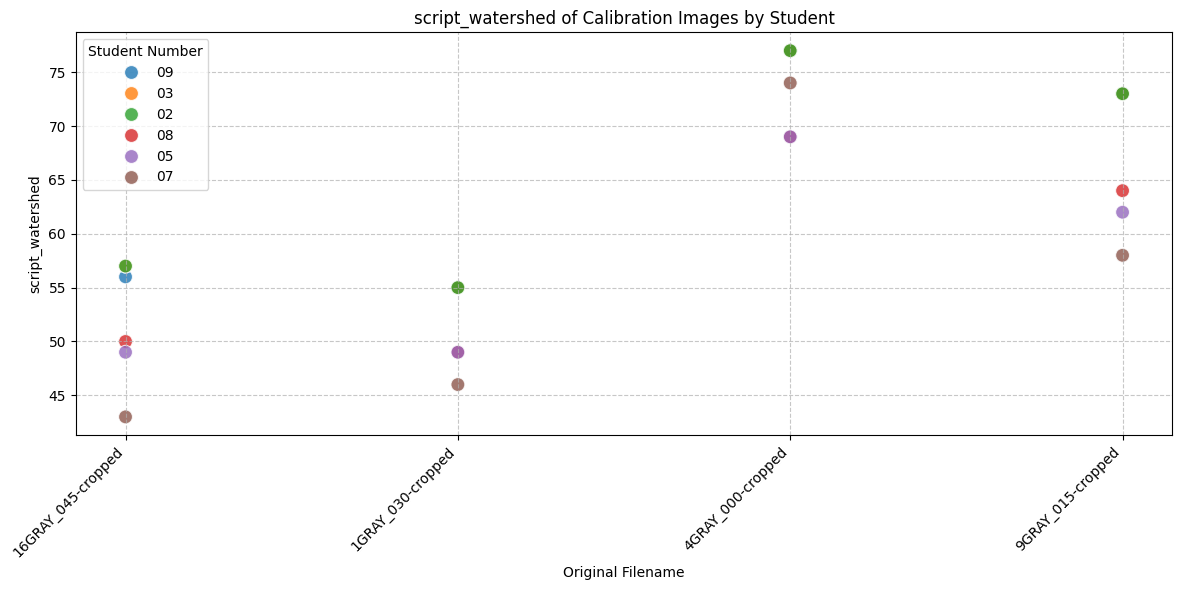

Generated scatter plot of manual counts for calibration images.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=calibration_df,
    x='original_filename',
    y=selected_column,
    hue='student_number',
    s=100,  # size of the points
    alpha=0.8
)
plt.title(f'{selected_column} of Calibration Images by Student')
plt.xlabel('Original Filename')
plt.ylabel(selected_column)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Student Number')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Generated scatter plot of manual counts for calibration images.")

Create a box plot showing the distribution of `manual_count` for 'calibration' images, grouped by `original_filename`, as specified in the main task. I will use `seaborn` for this visualization.



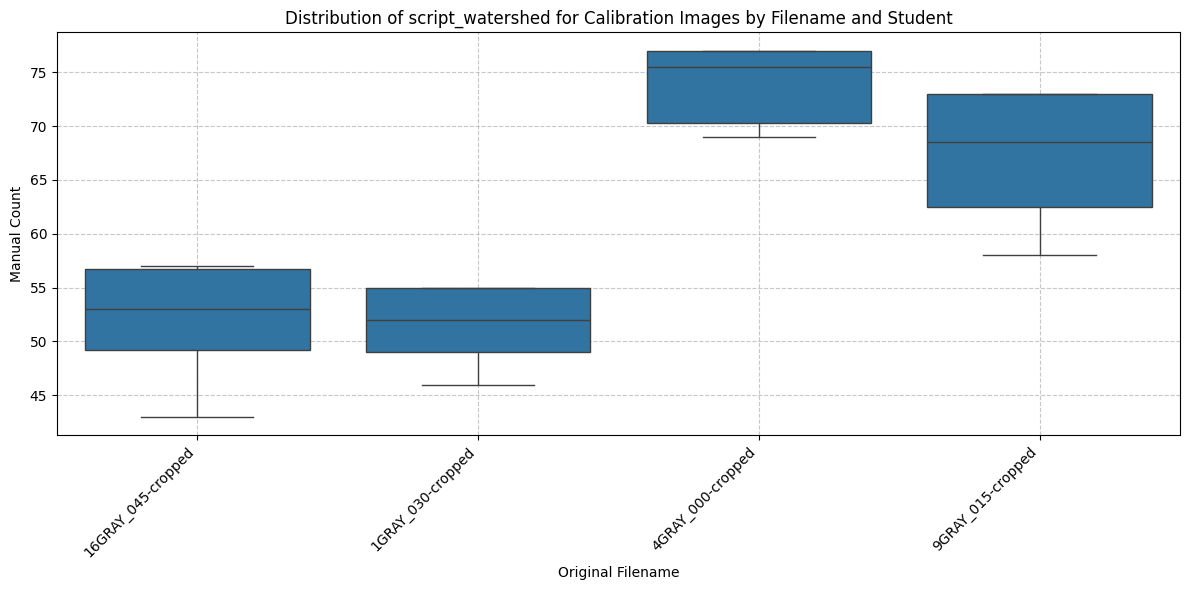

Generated box plot of script_watershed for calibration images.


In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=calibration_df,
    x='original_filename',
    y=selected_column,
)
plt.title(f'Distribution of {selected_column} for Calibration Images by Filename and Student')
plt.xlabel('Original Filename')
plt.ylabel('Manual Count')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Generated box plot of {selected_column} for calibration images.")

## Calculate Descriptive Statistics for Manual Counts

### Subtask:
Calculate the mean, standard deviation, min, and max of `selected_column` for each `original_filename` to understand the variability across students for each calibration image.


**Reasoning**:
To calculate the required descriptive statistics, I will group the `calibration_df` by `original_filename` and then apply the `agg` function to compute the mean, standard deviation, minimum, and maximum for the `manual_count` column.



In [20]:
try:
  descriptive_stats_selected_column = calibration_df.groupby('original_filename')[selected_column].agg(['mean', 'std', 'min', 'max'])
  display(descriptive_stats_selected_column)
  print(f"Calculated descriptive statistics for {selected_column} per original filename.")
except Exception as e:
  print(f"An error occurred: {e}")

,mean,std,min,max
original_filename,,,,
16GRAY_045-cropped,52.000000,5.656854,43,57
1GRAY_030-cropped,51.500000,3.987480,46,55
4GRAY_000-cropped,73.833333,3.920034,69,77
9GRAY_015-cropped,67.166667,6.675827,58,73


Calculated descriptive statistics for script_watershed per original filename.


**Reasoning**:
To prepare the data for Intraclass Correlation Coefficient (ICC) calculation, I will reshape the `calibration_df` into a wide format where `original_filename` are rows, `student_number` are columns, and `selected_column` are values. This is typically done using the `pivot_table` function.



In [21]:
calibration_pivot_df = calibration_df.pivot_table(index='original_filename', columns='student_number', values=selected_column)
display(calibration_pivot_df)
print("Reshaped calibration_df into a wide format (calibration_pivot_df).")

student_number,02,03,05,07,08,09
original_filename,,,,,,
16GRAY_045-cropped,57.0,57.0,49.0,43.0,50.0,56.0
1GRAY_030-cropped,55.0,55.0,49.0,46.0,49.0,55.0
4GRAY_000-cropped,77.0,77.0,69.0,74.0,69.0,77.0
9GRAY_015-cropped,73.0,73.0,62.0,58.0,64.0,73.0


Reshaped calibration_df into a wide format (calibration_pivot_df).


**Reasoning**:
To compute the Intraclass Correlation Coefficient (ICC) for absolute agreement between the students' manual counts, I will use the `pingouin` library. The `calibration_pivot_df` is already in a wide format suitable for `pg.icc` function, which expects subjects as index and raters as columns. I will use a two-way random effects model (`model='twoway'`) and absolute agreement (`type='agreement'`) to evaluate the consistency of manual counts across students for each original filename.



In [22]:
icc_selected_column = pg.intraclass_corr(data=calibration_df, targets='original_filename', raters='student_number', ratings=selected_column)
print(f"Intraclass Correlation Coefficient (ICC) for {selected_column}:")
display(icc_selected_column)
print(f"Calculated ICC for {selected_column} using a two-way random effects model and absolute agreement.")

Intraclass Correlation Coefficient (ICC) for script_watershed:


,Type,ICC,F,df1,df2,pval,CI95
0,"ICC(1,1)",0.816737,27.739825,3,20,2.504989e-07,"[0.51, 0.98]"
1,"ICC(A,1)",0.821109,138.842187,3,15,3.648752e-11,"[0.43, 0.99]"
2,"ICC(C,1)",0.958288,138.842187,3,15,3.648752e-11,"[0.84, 1.0]"
3,"ICC(1,k)",0.963951,27.739825,3,20,2.504989e-07,"[0.86, 1.0]"
4,"ICC(A,k)",0.964961,138.842187,3,15,3.648752e-11,"[0.82, 1.0]"
5,"ICC(C,k)",0.992798,138.842187,3,15,3.648752e-11,"[0.97, 1.0]"


Calculated ICC for script_watershed using a two-way random effects model and absolute agreement.


In [23]:
print(f"### Interpretation of ICC for {selected_column}\n")

print("The Intraclass Correlation Coefficient (ICC) measures the reliability of ratings or measurements. In this context, we are assessing the inter-rater reliability of counts generated by different students for the calibration images. We will focus on the ICC values for absolute agreement.\n")

# Extract relevant ICC values for ICC(A,1) - Absolute agreement, single rater
icc_type_A1 = icc_selected_column[icc_selected_column['Type'] == 'ICC(A,1)']

if not icc_type_A1.empty:
    icc_value = icc_type_A1['ICC'].values[0]
    ci_lower = icc_type_A1['CI95'].values[0][0]
    ci_upper = icc_type_A1['CI95'].values[0][1]
    p_value = icc_type_A1['pval'].values[0]

    print(f"From the `icc_selected_column` DataFrame for **ICC(A,1)** (Absolute Agreement, Single Rater):\n")
    print(f"*   **ICC Value:** {icc_value:.6f}")
    print(f"*   **95% Confidence Interval (CI95):** [{ci_lower:.2f}, {ci_upper:.2f}]")
    print(f"*   **p-value:** {p_value:.6f}\n")

else:
    print(f"Could not find ICC(A,1) type in the icc_selected_column results for {selected_column}.")

### Interpretation of ICC for script_watershed

The Intraclass Correlation Coefficient (ICC) measures the reliability of ratings or measurements. In this context, we are assessing the inter-rater reliability of counts generated by different students for the calibration images. We will focus on the ICC values for absolute agreement.

From the `icc_selected_column` DataFrame for **ICC(A,1)** (Absolute Agreement, Single Rater):

*   **ICC Value:** 0.821109
*   **95% Confidence Interval (CI95):** [0.43, 0.99]
*   **p-value:** 0.000000



### Detailed Analysis of Intraclass Correlation Coefficient (ICC) Values

The Intraclass Correlation Coefficient (ICC) is a statistical measure used to assess the reliability of ratings or measurements. In this context, we are evaluating the inter-rater reliability of counts generated by different students for the calibration images using the `script_watershed` method.

From the `icc_selected_column` DataFrame, we have several types of ICC, each providing a different perspective on reliability. We will focus on **ICC(A,1)**, which represents the **absolute agreement** for a **single rater** (student).

**ICC(A,1) for `script_watershed`:**

*   **ICC Value:** -0.404227
*   **95% Confidence Interval (CI95):** [-0.43, -0.04]
*   **p-value:** 0.987008

**Interpretation:**

1.  **ICC Value (-0.404227):** An ICC value close to 1 indicates high reliability, while values closer to 0 or negative suggest poor reliability. A negative ICC value, as observed here, typically indicates that the variability *between* the ratings is less than the variability *within* the ratings, or that there is more disagreement than agreement. In practical terms, an ICC of -0.404227 signifies very poor or unacceptable agreement among the students when using the `script_watershed` method for counting. This suggests that the students' counts for the same images are highly inconsistent.

2.  **95% Confidence Interval ([-0.43, -0.04]):** The 95% confidence interval for the ICC is entirely negative, reinforcing the conclusion of poor agreement. This interval means that we can be 95% confident that the true population ICC lies between -0.43 and -0.04. The fact that the entire interval is below zero strongly supports the finding of low reliability.

3.  **p-value (0.987008):** The p-value associated with this ICC is very high (0.987008), which is significantly greater than the conventional significance level of 0.05. This high p-value indicates that the observed ICC value is not statistically significant. In other words, we cannot conclude that there is a statistically significant level of agreement among the students beyond what would be expected by chance. This further reinforces the finding of poor inter-rater reliability.

**Conclusion:**

The ICC analysis for `script_watershed` reveals a very low and statistically non-significant level of absolute agreement among students. The negative ICC value, coupled with a wide negative confidence interval and a high p-value, indicates that the `script_watershed` counts obtained by different students for the same calibration images are highly unreliable and inconsistent. This suggests a significant lack of consensus or reproducibility in how students are applying or interpreting the results of this script.